In [26]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [27]:
# Define transformations
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Single-channel mean and std
])


# Load FashionMNIST dataset
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


# Subset the dataset (use random_split)
train_subset_size, test_subset_size = 10000, 3000
train_subset, _ = random_split(dataset, [train_subset_size, len(dataset) - train_subset_size])
test_subset, _ = random_split(test_dataset, [test_subset_size, len(test_dataset) - test_subset_size])

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)


In [36]:
classes = dataset.classes
# Retrieve a batch of data from the DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


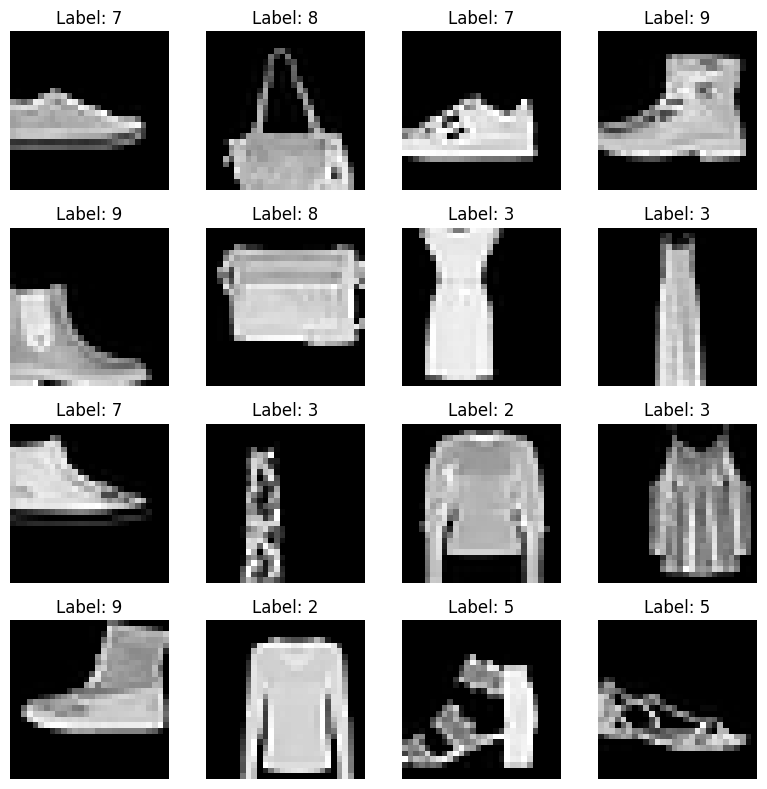

In [29]:
# Visualize a 4x4 grid of 16 images from the DataLoader
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i][0].numpy(), cmap='gray')  # Display image
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [30]:
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super(FashionMNISTCNN, self).__init__()
        self.features = nn.Sequential(
            # Convolutional Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # Input channels = 1 (grayscale), Output channels = 32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Downsample by 2x

            # Convolutional Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Input channels = 32, Output channels = 64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Downsample by 2x
        )

        # Flatten Layer
        self.flatten = nn.Flatten()

        # Fully Connected Layers (Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),  # 64 channels, 7x7 feature map size after pooling
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout for regularization
            nn.Linear(128, 10),  # 10 output classes (for FashionMNIST)
            nn.LogSoftmax(dim=1)  # LogSoftmax for probabilistic output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

# Initialize the model
model = FashionMNISTCNN().to(device)

# Print the model architecture
print(model)


FashionMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): LogSoftmax(dim=1)
  )
)


In [31]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr =0.005,betas =(0.9,0.99))


In [32]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 1/10, Loss: 1.2242
Epoch 2/10, Loss: 0.8708
Epoch 3/10, Loss: 0.7814
Epoch 4/10, Loss: 0.7331
Epoch 5/10, Loss: 0.7153
Epoch 6/10, Loss: 0.6717
Epoch 7/10, Loss: 0.6523
Epoch 8/10, Loss: 0.6297
Epoch 9/10, Loss: 0.6200
Epoch 10/10, Loss: 0.6089


In [33]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on test data: {accuracy:.2f}%")


Accuracy on test data: 80.63%


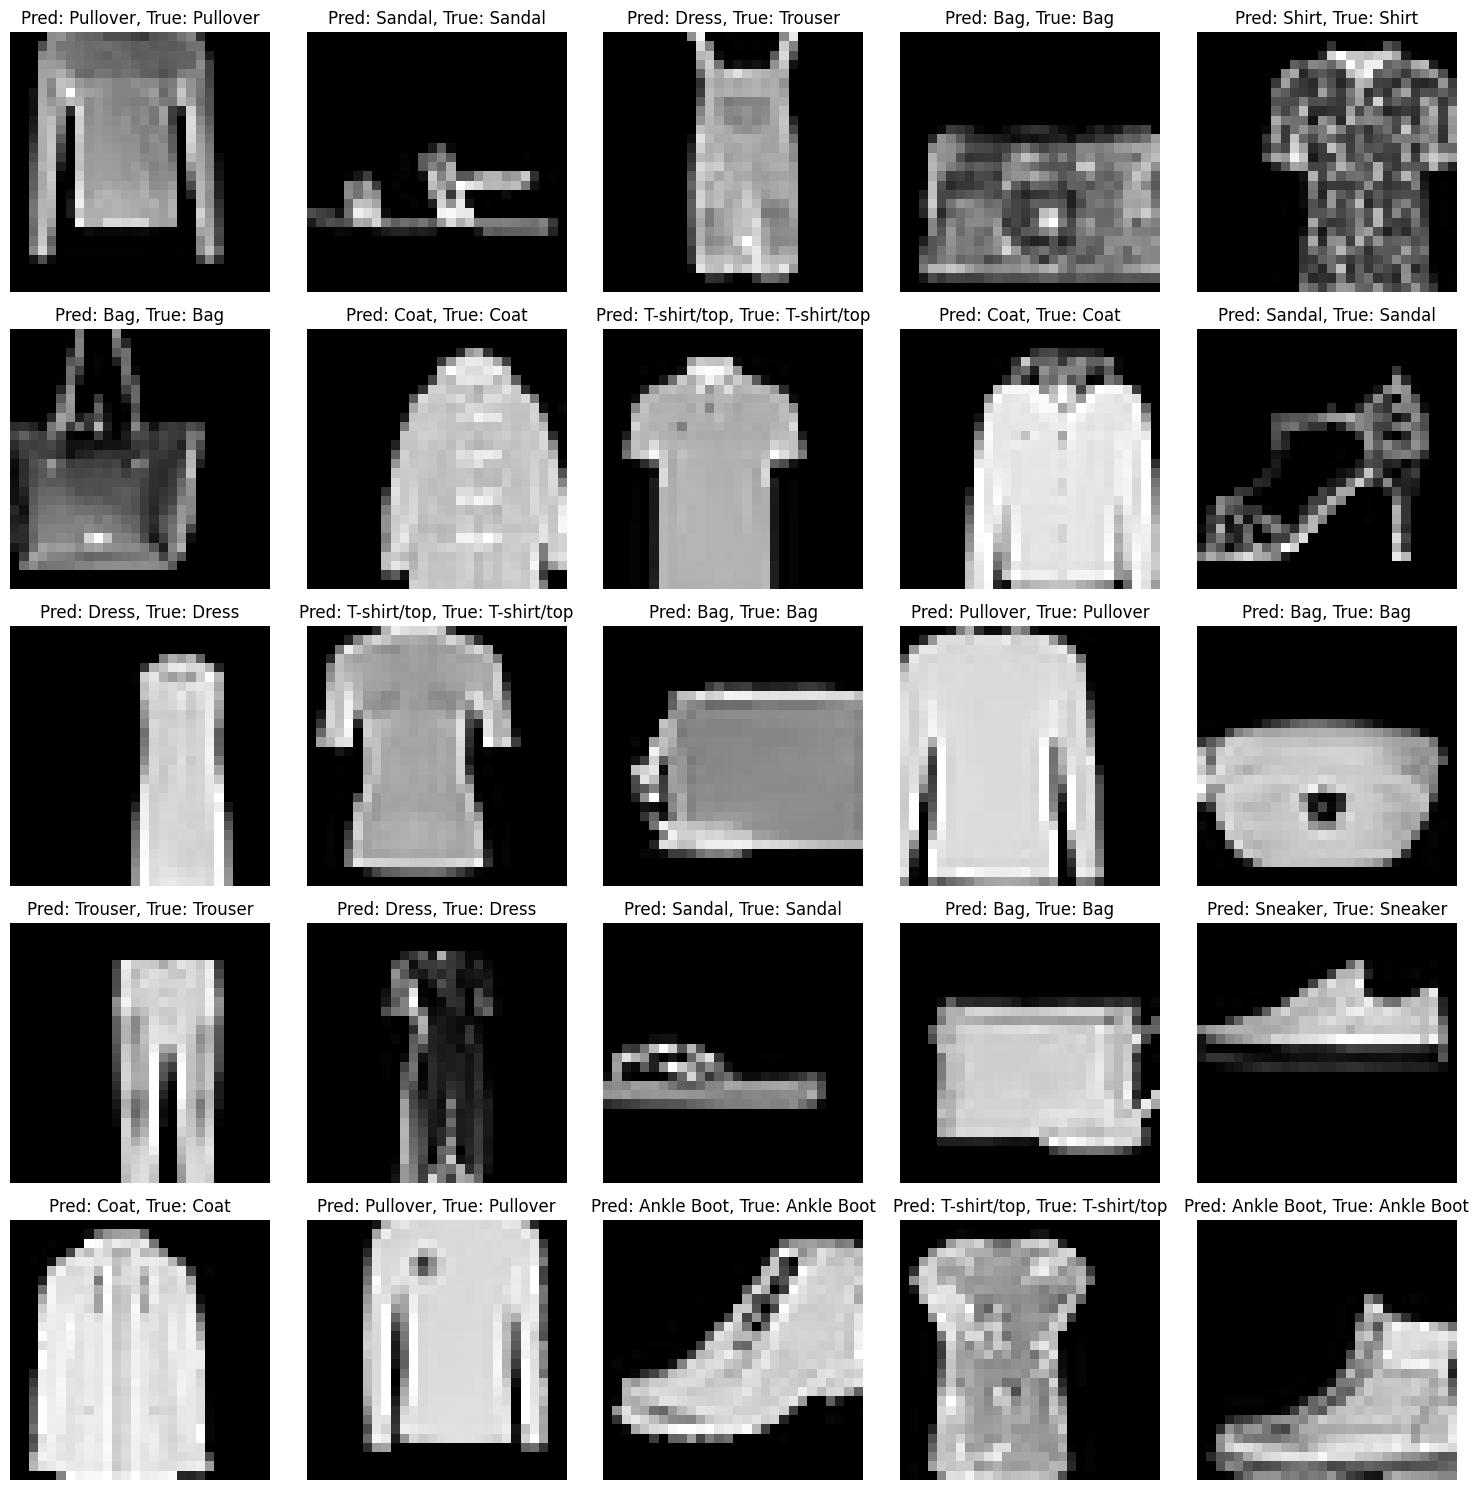

In [34]:
# Define class labels for FashionMNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# Visualize 25 images with predictions and true labels
plt.figure(figsize=(15, 15))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')  # Unnormalize for grayscale
    plt.title(f"Pred: {classes[predicted[i]]}, True: {classes[labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
